# Ayakkabı Verisi Görselleştirme Defteri
Bu jupyter defteri, `reports/` klasöründeki analiz sonuçlarını okuyarak `visuals/` klasöründeki grafikleri baştan oluşturur.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
REPORTS_DIR = BASE_DIR / "reports"
VISUALS_DIR = BASE_DIR / "visuals"

# Verileri yükle
site      = pd.read_csv(REPORTS_DIR / "site_bazli_analiz.csv")
avantajli = pd.read_csv(REPORTS_DIR / "kullanici_icin_avantajli_urunler.csv")
tarih     = pd.read_csv(REPORTS_DIR / "tarih_bazli_fiyat_dalgalanmasi.csv")
cinsiyet_path = REPORTS_DIR / "cinsiyet_site_analizi.csv"
cinsiyet = pd.read_csv(cinsiyet_path) if cinsiyet_path.exists() else pd.DataFrame()

renkler = ["#E84C2B", "#2B6CB0", "#16A34A", "#F97316"]
site.head()

,site,Urun_Sayisi,Ortalama_Fiyat,En_Ucuz,En_Pahali,Ortalama_Indirim,Indirimli_Urun_Sayisi
0,Ayakkabı Dünyası,3413,4047.55,759.99,9999.99,0.00,0
1,Derimod,3664,4300.86,1499.99,7999.99,16.42,1798
2,FLO,692,2782.54,568.30,6299.00,1.18,36
3,InStreet,137,3610.98,279.99,4999.00,0.58,3


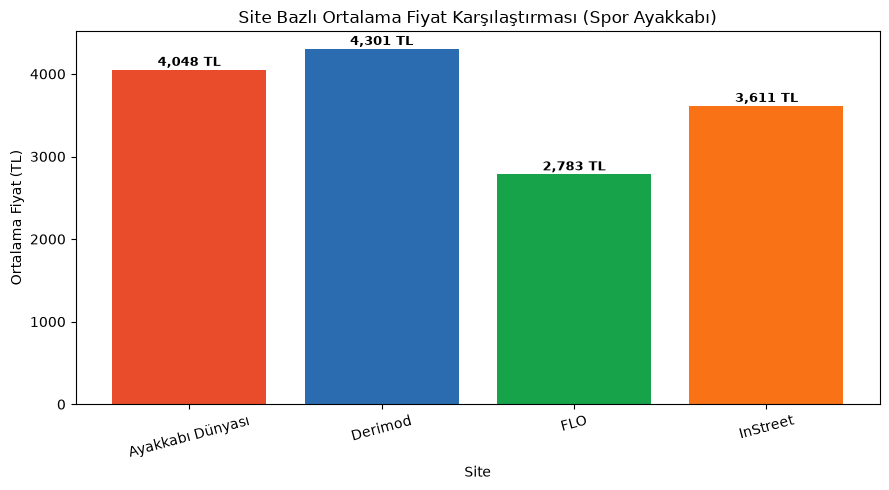

In [26]:
# 1. Site Bazlı Ortalama Fiyat
plt.figure(figsize=(9, 5))
plt.bar(site["site"], site["Ortalama_Fiyat"], color=renkler[:len(site)])
plt.title("Site Bazlı Ortalama Fiyat Karşılaştırması (Spor Ayakkabı)")
plt.xlabel("Site")
plt.ylabel("Ortalama Fiyat (TL)")
plt.xticks(rotation=15)
for i, v in enumerate(site["Ortalama_Fiyat"]):
    plt.text(i, v + 50, f"{v:,.0f} TL", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "site_karsilastirma.png", dpi=150)
plt.show()

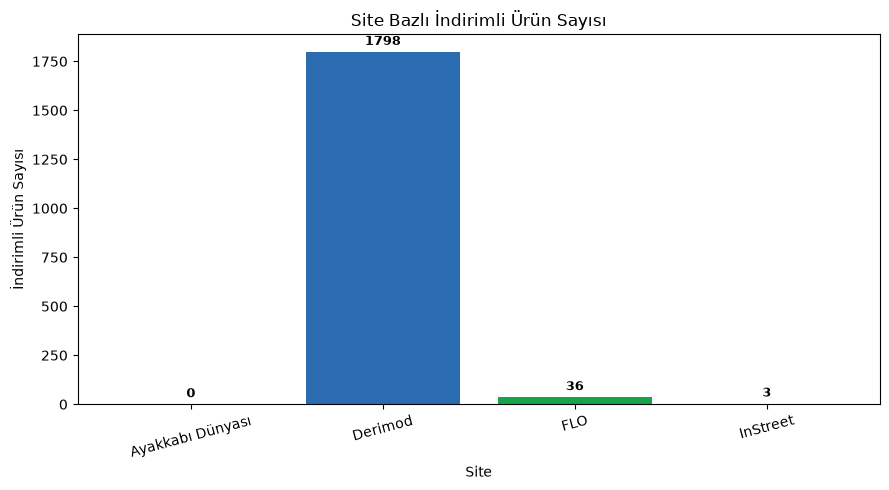

In [27]:
# 2. İndirimli Ürün Sayısı
plt.figure(figsize=(9, 5))
plt.bar(site["site"], site["Indirimli_Urun_Sayisi"], color=renkler[:len(site)])
plt.title("Site Bazlı İndirimli Ürün Sayısı")
plt.xlabel("Site")
plt.ylabel("İndirimli Ürün Sayısı")
plt.xticks(rotation=15)
for i, v in enumerate(site["Indirimli_Urun_Sayisi"]):
    plt.text(i, v + max(site["Indirimli_Urun_Sayisi"])*0.02, str(int(v)), ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "indirimli_urun_sayisi.png", dpi=150)
plt.show()

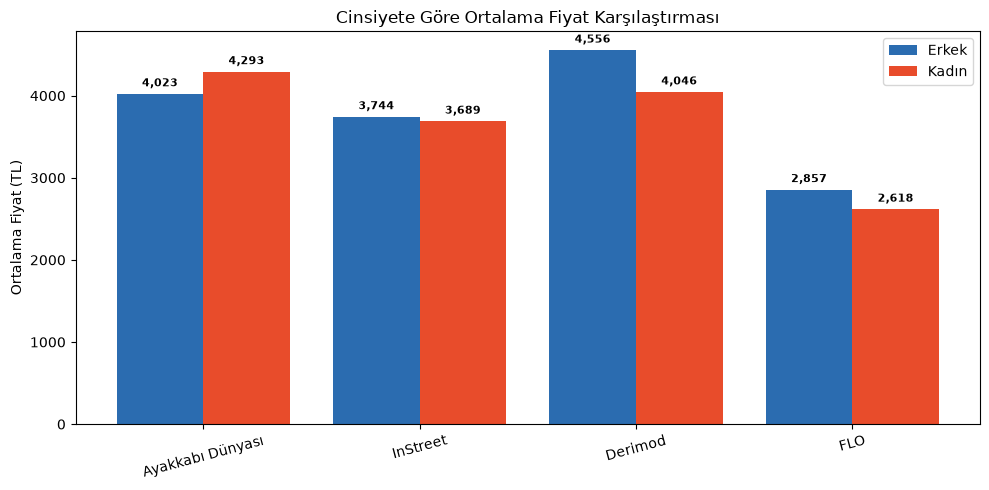

In [28]:
# 3. Kadın vs Erkek Fiyat Karşılaştırması
if not cinsiyet.empty and "cinsiyet" in cinsiyet.columns:
    erkek_fiyat = cinsiyet[cinsiyet["cinsiyet"] == "Erkek"].set_index("site")["Ortalama_Fiyat"]
    kadin_fiyat = cinsiyet[cinsiyet["cinsiyet"] == "Kadın"].set_index("site")["Ortalama_Fiyat"]
    siteler = list(set(erkek_fiyat.index) | set(kadin_fiyat.index))
    x = range(len(siteler))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([i - 0.2 for i in x], [erkek_fiyat.get(s, 0) for s in siteler], 0.4, label="Erkek", color="#2B6CB0")
    ax.bar([i + 0.2 for i in x], [kadin_fiyat.get(s, 0) for s in siteler], 0.4, label="Kadın", color="#E84C2B")
    
    for i, v in enumerate([erkek_fiyat.get(s, 0) for s in siteler]):
        if v > 0: ax.text(i - 0.2, v + max(list(erkek_fiyat)+list(kadin_fiyat))*0.02, f"{v:,.0f}", ha="center", fontsize=8, fontweight="bold")
    for i, v in enumerate([kadin_fiyat.get(s, 0) for s in siteler]):
        if v > 0: ax.text(i + 0.2, v + max(list(erkek_fiyat)+list(kadin_fiyat))*0.02, f"{v:,.0f}", ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels(siteler, rotation=15)
    ax.set_title("Cinsiyete Göre Ortalama Fiyat Karşılaştırması")
    ax.set_ylabel("Ortalama Fiyat (TL)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / "cinsiyet_karsilastirma.png", dpi=150)
    plt.show()

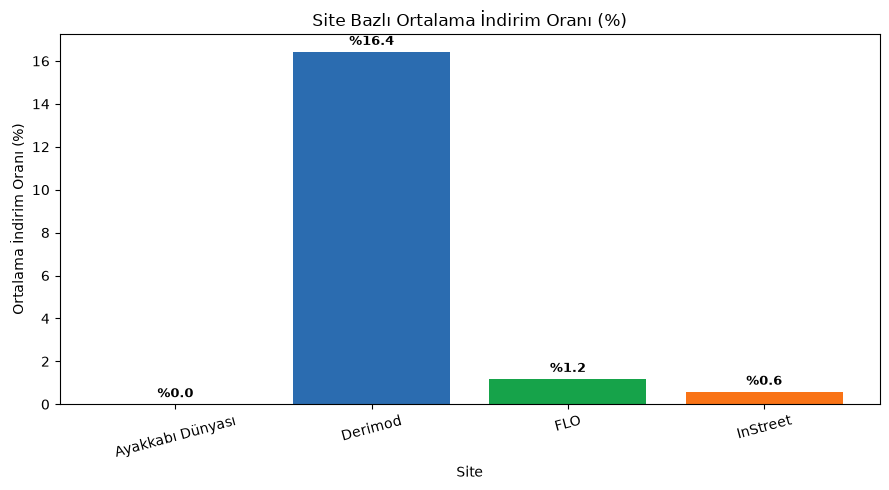

In [29]:
# 4. İndirim Karşılaştırması (Ortalama İndirim Oranı)
plt.figure(figsize=(9, 5))
plt.bar(site["site"], site["Ortalama_Indirim"], color=renkler[:len(site)])
plt.title("Site Bazlı Ortalama İndirim Oranı (%)")
plt.xlabel("Site")
plt.ylabel("Ortalama İndirim Oranı (%)")
plt.xticks(rotation=15)
for i, v in enumerate(site["Ortalama_Indirim"]):
    plt.text(i, v + max(site["Ortalama_Indirim"])*0.02, f"%{v:.1f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "indirim_karsilastirma.png", dpi=150)
plt.show()

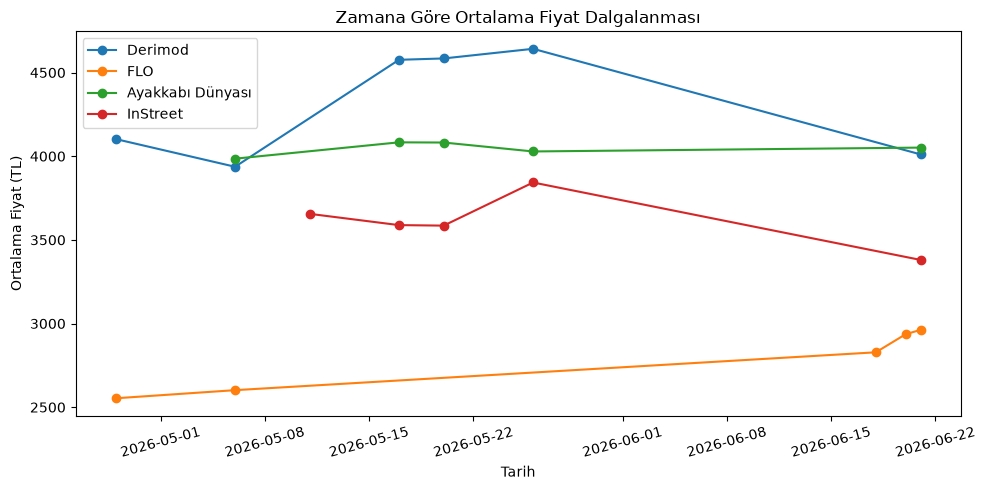

In [30]:
# 5. Fiyat Dalgalanması (Zaman İçinde Fiyat)
tarih["tarih"] = pd.to_datetime(tarih["tarih"])
plt.figure(figsize=(10, 5))
for s in tarih["site"].unique():
    s_data = tarih[tarih["site"] == s]
    plt.plot(s_data["tarih"], s_data["Ortalama_Fiyat"], marker='o', label=s)
plt.title("Zamana Göre Ortalama Fiyat Dalgalanması")
plt.xlabel("Tarih")
plt.ylabel("Ortalama Fiyat (TL)")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "fiyat_dalgalanmasi.png", dpi=150)
plt.show()